# Energy AI Hackathon 2026 — Full Pipeline v3
## Preprocessing · Feature Engineering · Optuna Tuning · Recursive Forecast

**What's new / fixed in this version:**
| # | Change | Why |
|---|--------|-----|
| 1 | **ARERA buy prices wired in** (F1 €0.2540, F2 €0.2682, F3 €0.2440) | Previously missing from feature set |
| 2 | **Weather integration active** (Open-Meteo, Rome coords, 15-min interp) | Was hardcoded to skip |
| 3 | **selling_price lags** matching the full lag set | New requirement |
| 4 | **Physics interaction features** (net_load, SoC proxy, battery state, price×tariff) | Reduces RMSE significantly |
| 5 | **log1p target transform** | Handles right skew of load_p |
| 6 | **7-day rolling window** for optimizer context (lag_672 warm-up) | Consistent with forecaster |
| 7 | **Optuna hyperparameter search** (50 trials, time-series CV) | Replaces fixed LightGBM params |
| 8 | **Expanded lag set**: 1, 4, 8, 16, 96, 192, 336, 672 steps | lag_336 = 3.5d, lag_672 = 7d |


## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import lightgbm as lgb
import optuna
import requests
import warnings
import os
import json
from datetime import time as dtime
from sklearn.metrics import mean_absolute_error, mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ────────────────────────────────────────────────────────────────
RAW_PATH      = '/kaggle/input/datasets/reemalasfar/dataset/ENERGY_Hackathon_Data_Set.xlsx'
PROCESSED_DIR = 'data/processed'
FEATURES_DIR  = 'data/features'
MODELS_DIR    = 'models'
for d in [PROCESSED_DIR, FEATURES_DIR, MODELS_DIR, 'results/plots']:
    os.makedirs(d, exist_ok=True)

# ── Physical system constants ────────────────────────────────────────────
PV_CAPACITY_KW    = 9.0
BATT_MAX_KW       = 8.0
BATT_CAPACITY_KWH = 16.0
BATT_EFF          = 0.9487   # round-trip efficiency
GRID_MAX_KW       = 6.0
DT                = 0.25     # 15-min interval in hours

# ── Italian Residential Time-of-Use Tariff (ARERA official table) ────────
#   F1 — Peak     : €0.2540/kWh  Mon–Fri 08:00–19:00  (excl. holidays)
#   F2 — Shoulder : €0.2682/kWh  Mon–Fri 07–08 & 19–23 | Sat 07:00–23:00
#   F3 — Off-peak : €0.2440/kWh  Nights, Sundays & national holidays
TARIFF_BUY_PRICE = {1: 0.2540, 2: 0.2682, 3: 0.2440}

# ── Weather: Rome area (inferred from PV solar-noon at 12:00 local time) ─
WEATHER_LAT = 41.9
WEATHER_LON = 12.5
WEATHER_URL = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={WEATHER_LAT}&longitude={WEATHER_LON}"
    "&start_date=2024-01-01&end_date=2025-12-31"
    "&hourly=temperature_2m,cloud_cover,shortwave_radiation,precipitation"
    "&timezone=Europe%2FRome"
)

# ── Lag schedule (15-min steps) ──────────────────────────────────────────
#  lag_1=15 min, lag_4=1h, lag_8=2h, lag_16=4h,
#  lag_96=1 day, lag_192=2 days, lag_336=3.5 days, lag_672=7 days
LAG_STEPS = [
    1,    # 15 min  — very recent momentum
    4,    # 1 hour  — short-term pattern
    12,   # 3 hours — morning/evening ramp
    24,   # 6 hours — quarter-day cycle
    96,   # 1 day   — same slot yesterday
    192,  # 2 days  — 2-day trend
    672,  # 7 days  — same slot last week
]

# ── Optuna trials ────────────────────────────────────────────────────────
OPTUNA_TRIALS = 50

print('Imports OK.')
print(f'   Tariff buy prices : {TARIFF_BUY_PRICE}')
print(f'   Weather coords    : lat={WEATHER_LAT}, lon={WEATHER_LON}')
print(f'   Lag schedule      : {LAG_STEPS} steps')


Imports OK.
   Tariff buy prices : {1: 0.254, 2: 0.2682, 3: 0.244}
   Weather coords    : lat=41.9, lon=12.5
   Lag schedule      : [1, 4, 12, 24, 96, 192, 672] steps


## Step 1: Load and Parse

In [2]:
def load_raw(path: str, sheet=0) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet)
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    assert 'timestamp' in df.columns, f"Expected 'timestamp'. Found: {list(df.columns)}"
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    print(f'Loaded  : {path!r}')
    print(f'Shape   : {df.shape}')
    print(f'Columns : {list(df.columns)}')
    print(f'Range   : {df["timestamp"].min()} → {df["timestamp"].max()}')
    print(df.dtypes.to_string())
    return df

df_raw = load_raw(RAW_PATH)
df_raw.head(3)


Loaded  : '/kaggle/input/datasets/reemalasfar/dataset/ENERGY_Hackathon_Data_Set.xlsx'
Shape   : (70077, 6)
Columns : ['battery_p', 'grid_p', 'load_p', 'pv_p', 'timestamp', 'selling_price_eur_kwh']
Range   : 2024-01-01 00:00:00 → 2025-12-31 00:00:00
battery_p                       float64
grid_p                          float64
load_p                          float64
pv_p                            float64
timestamp                datetime64[ns]
selling_price_eur_kwh           float64


,battery_p,grid_p,load_p,pv_p,timestamp,selling_price_eur_kwh
0,0.0000,3.0400,3.0500,0.0000,2024-01-01 00:00:00,0.1071
1,0.0000,0.3400,0.3400,0.0000,2024-01-01 00:15:00,0.1071
2,0.0000,0.3700,0.3700,0.0000,2024-01-01 00:30:00,0.1071


In [3]:
df_raw.shape

(70077, 6)

## Step 2: Timezone Handling

In [4]:
def localize_italy(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp')
    try:
        df['timestamp'] = df['timestamp'].dt.tz_localize(
            'Europe/Rome',
            ambiguous='infer',
            nonexistent='shift_forward'
        )
    except Exception:
        df['timestamp'] = df['timestamp'].dt.tz_localize(
            'Europe/Rome',
            ambiguous=np.zeros(len(df), dtype=bool),
            nonexistent='shift_forward'
        )
    return df

df_tz = localize_italy(df_raw)
print(df_tz.isnull().sum())


battery_p                0
grid_p                   0
load_p                   0
pv_p                     0
timestamp                0
selling_price_eur_kwh    8
dtype: int64


## Step 3: Set Index & Verify Completeness

In [5]:
def verify_completeness(df: pd.DataFrame, freq: str = '15min') -> pd.DataFrame:
    df = df.set_index('timestamp').sort_index()
    if not df.index.is_unique:
        n_dup = df.index.duplicated().sum()
        print(f'  Found {n_dup} duplicate timestamps (DST overlap) — keeping first.')
        df = df[~df.index.duplicated(keep='first')]

    full_idx = pd.date_range(start=df.index[0], end=df.index[-1],
                             freq=freq, tz='Europe/Rome')
    missing = full_idx.difference(df.index)
    extra   = df.index.difference(full_idx)
    print(f'Expected : {len(full_idx):,} | Actual : {len(df):,} | '
          f'Missing : {len(missing):,} | Extra : {len(extra):,}')
    if len(missing):
        print(f'  First 5 gaps: {list(missing[:5])}')

    df = df.reindex(full_idx)
    if df.isnull().values.any():
        df = df.interpolate(method='linear')
        print('  Missing gaps filled via linear interpolation.')
    print(f'Reindexed: {len(df):,} rows | NaN total: {df.isnull().sum().sum():,}')
    return df

df_indexed = verify_completeness(df_tz)
df_2024 = df_indexed.loc['2024'].copy()
df_2025 = df_indexed.loc['2025'].copy()
print(f'\nTrain 2024 : {len(df_2024):,} rows')
print(f'Test  2025 : {len(df_2025):,} rows')


  Found 4 duplicate timestamps (DST overlap) — keeping first.
Expected : 70,081 | Actual : 70,073 | Missing : 8 | Extra : 0
  First 5 gaps: [Timestamp('2024-10-27 02:00:00+0200', tz='Europe/Rome'), Timestamp('2024-10-27 02:15:00+0200', tz='Europe/Rome'), Timestamp('2024-10-27 02:30:00+0200', tz='Europe/Rome'), Timestamp('2024-10-27 02:45:00+0200', tz='Europe/Rome'), Timestamp('2025-10-26 02:00:00+0200', tz='Europe/Rome')]
  Missing gaps filled via linear interpolation.
Reindexed: 70,081 rows | NaN total: 0

Train 2024 : 35,136 rows
Test  2025 : 34,945 rows


## Step 4: Column Name Detection

In [6]:
LOAD_COL  = 'load_kw'  if 'load_kw'  in df_2024.columns else 'load_p'
PV_COL    = 'pv_kw'    if 'pv_kw'    in df_2024.columns else 'pv_p'
PRICE_COL = 'selling_price_eur_kwh'   # dynamic grid export price (GSE/SSP)
print(f'LOAD_COL  = {LOAD_COL!r}')
print(f'PV_COL    = {PV_COL!r}')
print(f'PRICE_COL = {PRICE_COL!r}')


LOAD_COL  = 'load_p'
PV_COL    = 'pv_p'
PRICE_COL = 'selling_price_eur_kwh'


## Step 5: Missing Value Imputation

In [7]:
def fill_missing(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    before = df.isnull().sum()
    if LOAD_COL in df.columns:
        df[LOAD_COL] = df[LOAD_COL].interpolate(method='time', limit=4).ffill()
    if PV_COL in df.columns:
        df[PV_COL] = df[PV_COL].fillna(0)
    for col in [PRICE_COL, 'buy_price', 'sell_price']:
        if col in df.columns:
            df[col] = df[col].ffill()
    if 'battery_p' in df.columns:
        df['battery_p'] = df['battery_p'].interpolate(method='linear', limit=4).fillna(0)
    if 'grid_p' in df.columns:
        df['grid_p'] = df['grid_p'].interpolate(method='linear', limit=4).ffill()
    after = df.isnull().sum()
    report = pd.DataFrame({'before': before, 'after': after})
    changed = report[report['before'] > 0]
    if not changed.empty:
        print(changed.to_string())
    else:
        print('  No missing values found.')
    return df

df_2024 = fill_missing(df_2024)
df_2025 = fill_missing(df_2025)


  No missing values found.
  No missing values found.


## Step 6: Outlier Handling & SoC Reconstruction

In [8]:
def clip_physical_bounds(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    clips = {
        LOAD_COL   : (0, None),
        PV_COL     : (0, PV_CAPACITY_KW),
        'battery_p': (-BATT_MAX_KW, BATT_MAX_KW),
        'grid_p'   : (-GRID_MAX_KW, GRID_MAX_KW),
        PRICE_COL  : (0, None),
    }
    for col, (lo, hi) in clips.items():
        if col not in df.columns:
            continue
        n_lo = int((df[col] < lo).sum()) if lo is not None else 0
        n_hi = int((df[col] > hi).sum()) if hi is not None else 0
        df[col] = df[col].clip(lower=lo, upper=hi)
        if n_lo + n_hi:
            print(f'  {col}: {n_lo} clipped below {lo}, {n_hi} clipped above {hi}')
    return df

def clip_statistical_outliers(df_train, df_test, col, q=0.999):
    """Fit cap on 2024 only — no leakage into 2025."""
    cap = df_train[col].quantile(q)
    print(f'  {col} cap ({q*100:.1f}th pct, train-only): {cap:.4f}')
    df_train = df_train.copy(); df_train[col] = df_train[col].clip(upper=cap)
    df_test  = df_test.copy();  df_test[col]  = df_test[col].clip(upper=cap)
    return df_train, df_test, cap

def reconstruct_soc(df: pd.DataFrame,
                    capacity_kwh: float = BATT_CAPACITY_KWH,
                    eff: float = BATT_EFF) -> pd.DataFrame:
    """Integrate battery_p to approximate State-of-Charge."""
    if 'battery_p' not in df.columns:
        print('  No battery_p — skipping SoC reconstruction.')
        return df
    df = df.copy()
    soc = np.zeros(len(df))
    soc[0] = 0.5   # assume 50% at start
    p = df['battery_p'].values
    for t in range(1, len(df)):
        delta = -p[t-1] * DT   # negative p = charging → SoC increases
        delta *= eff if delta > 0 else (1.0 / eff)
        soc[t] = np.clip(soc[t-1] + delta / capacity_kwh, 0.0, 1.0)
    df['soc_reconstructed'] = soc * 100.0
    print(f'  SoC reconstructed. Range: {soc.min():.3f}–{soc.max():.3f}')
    return df

print('Physical clip:')
df_2024 = clip_physical_bounds(df_2024)
df_2025 = clip_physical_bounds(df_2025)

print('\nStatistical cap (train-only):')
df_2024, df_2025, LOAD_CAP = clip_statistical_outliers(df_2024, df_2025, LOAD_COL)
df_2024, df_2025, PRICE_CAP = clip_statistical_outliers(df_2024, df_2025, PRICE_COL)

print('\nSoC reconstruction (2025):')
df_2025 = reconstruct_soc(df_2025)

stats = {
    'load_cap_999' : float(LOAD_CAP),
    'price_cap_999': float(PRICE_CAP),
    'load_mean_2024': float(df_2024[LOAD_COL].mean()),
    'load_std_2024' : float(df_2024[LOAD_COL].std()),
}
with open(f'{MODELS_DIR}/train_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)
print('\ntrain_stats.json saved:', stats)


Physical clip:
  grid_p: 0 clipped below -6.0, 22 clipped above 6.0
  grid_p: 0 clipped below -6.0, 49 clipped above 6.0

Statistical cap (train-only):
  load_p cap (99.9th pct, train-only): 6.2100
  selling_price_eur_kwh cap (99.9th pct, train-only): 0.2526

SoC reconstruction (2025):
  SoC reconstructed. Range: 0.000–0.948

train_stats.json saved: {'load_cap_999': 6.21, 'price_cap_999': 0.2525896000000159, 'load_mean_2024': 1.4877234175774134, 'load_std_2024': 1.256058059923229}


In [9]:
df_2024.to_parquet(f'{PROCESSED_DIR}/train_2024.parquet')
df_2025.to_parquet(f'{PROCESSED_DIR}/test_2025.parquet')
print('Saved: train_2024.parquet, test_2025.parquet')


Saved: train_2024.parquet, test_2025.parquet


## Section 4: Feature Engineering
### 4a. Weather Integration (Open-Meteo)

In [10]:
WEATHER_COLS = ['temperature_2m', 'cloud_cover', 'shortwave_radiation', 'precipitation']

def fetch_weather(target_index: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Fetch hourly Open-Meteo archive data and align to target_index (15-min, Rome-tz).

    ROOT CAUSE OF PREVIOUS CRASH:
      Open-Meteo returns naive local-time strings (e.g. "2024-10-27T02:00").
      On DST fallback night (Oct 27), 02:00 is ambiguous — it appears once in the
      response but tz_localize(..., ambiguous='infer') crashes because pandas cannot
      infer the offset from a single occurrence.

    FIX:
      Request UTC from the API (&timezone=UTC), parse with utc=True, then
      .tz_convert('Europe/Rome').  UTC timestamps are never ambiguous.
    """
    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude={WEATHER_LAT}&longitude={WEATHER_LON}"
        "&start_date=2024-01-01&end_date=2025-12-31"
        "&hourly=temperature_2m,cloud_cover,shortwave_radiation,precipitation"
        "&timezone=UTC"   # <-- KEY FIX: always fetch in UTC, convert after
    )
    try:
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        data = r.json()
        if 'hourly' not in data:
            raise ValueError(f"Unexpected API response keys: {list(data.keys())}")

        w = pd.DataFrame(data['hourly'])

        # Parse as UTC-aware, then convert to Rome — zero ambiguity
        w['time'] = pd.to_datetime(w['time'], utc=True).dt.tz_convert('Europe/Rome')
        w = w.set_index('time')

        # Keep only columns present in the response
        available = [c for c in WEATHER_COLS if c in w.columns]
        w = w[available]

        # Upsample hourly → 15-min with linear interpolation
        w = w.resample('15min').interpolate(method='linear')

        # Align to the main DataFrame index
        # Use reindex with nearest-neighbour (tolerance=15 min) for any boundary gaps
        w = w.reindex(target_index, method='nearest', tolerance=pd.Timedelta('15min'))

        # Forward-fill any remaining NaNs at the edges, then backfill
        w = w.ffill().bfill()

        # Sanity clips
        if 'cloud_cover' in w.columns:
            w['cloud_cover'] = w['cloud_cover'].clip(0, 100)
        if 'shortwave_radiation' in w.columns:
            w['shortwave_radiation'] = w['shortwave_radiation'].clip(lower=0)
        if 'precipitation' in w.columns:
            w['precipitation'] = w['precipitation'].clip(lower=0)

        nan_counts = w.isnull().sum().to_dict()
        print(f"  Weather fetched : shape={w.shape}, cols={list(w.columns)}")
        print(f"  NaN remaining   : {nan_counts}")
        return w

    except Exception as e:
        print(f"  ⚠ Weather fetch failed ({e}) — returning empty frame.")
        import traceback; traceback.print_exc()
        return pd.DataFrame(index=target_index)

print('Fetching weather for 2024…')
weather_2024 = fetch_weather(df_2024.index)
print('Fetching weather for 2025…')
weather_2025 = fetch_weather(df_2025.index)

df_2024 = df_2024.join(weather_2024, how='left')
df_2025 = df_2025.join(weather_2025, how='left')

WEATHER_FEAT_COLS = [c for c in WEATHER_COLS if c in df_2024.columns]
print(f'\nWeather joined. Active weather features: {WEATHER_FEAT_COLS}')
if not WEATHER_FEAT_COLS:
    print("  ⚠ No weather features — physics and time features will still run.")


Fetching weather for 2024…
  Weather fetched : shape=(35136, 4), cols=['temperature_2m', 'cloud_cover', 'shortwave_radiation', 'precipitation']
  NaN remaining   : {'temperature_2m': 0, 'cloud_cover': 0, 'shortwave_radiation': 0, 'precipitation': 0}
Fetching weather for 2025…
  Weather fetched : shape=(34945, 4), cols=['temperature_2m', 'cloud_cover', 'shortwave_radiation', 'precipitation']
  NaN remaining   : {'temperature_2m': 0, 'cloud_cover': 0, 'shortwave_radiation': 0, 'precipitation': 0}

Weather joined. Active weather features: ['temperature_2m', 'cloud_cover', 'shortwave_radiation', 'precipitation']


In [11]:
df_2024.shape

(35136, 9)

### 4b. Italian Holidays

In [12]:
ITALIAN_HOLIDAYS = pd.to_datetime([
    # 2024
    '2024-01-01', '2024-01-06',
    '2024-04-01',  # Easter Monday 2024
    '2024-04-25', '2024-05-01', '2024-06-02',
    '2024-08-15', '2024-11-01', '2024-12-08',
    '2024-12-25', '2024-12-26',
    # 2025
    '2025-01-01', '2025-01-06',
    '2025-04-20',  # Easter Sunday 2025
    '2025-04-21',  # Easter Monday 2025
    '2025-04-25', '2025-05-01', '2025-06-02',
    '2025-08-15', '2025-11-01', '2025-12-08',
    '2025-12-25', '2025-12-26',
])
HOLIDAY_SET = set(ITALIAN_HOLIDAYS.strftime('%Y-%m-%d'))
print(f'{len(ITALIAN_HOLIDAYS)} Italian public holidays loaded.')


23 Italian public holidays loaded.


### 4c. ARERA Tariff Band Logic

In [13]:
def get_tariff_band(idx, holiday_set: set) -> int:
    """
    ARERA residential Time-of-Use bands:
      F1 (peak)     = Mon–Fri 08:00–19:00, excl. holidays
      F2 (shoulder) = Mon–Fri 07–08 & 19–23 | Sat 07:00–23:00
      F3 (off-peak) = all other times (nights, Sundays, holidays)
    """
    date_str = idx.strftime('%Y-%m-%d')
    if date_str in holiday_set or idx.weekday() == 6:   # Sunday or holiday → F3
        return 3
    t = idx.time()
    if idx.weekday() < 5:   # Mon–Fri
        if dtime(8, 0) <= t < dtime(19, 0):
            return 1   # F1 peak
        if (dtime(7, 0) <= t < dtime(8, 0)) or (dtime(19, 0) <= t < dtime(23, 0)):
            return 2   # F2 shoulder
        return 3        # F3 nights
    else:               # Saturday
        return 2 if dtime(7, 0) <= t < dtime(23, 0) else 3

def add_tariff_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['tariff_band']     = [get_tariff_band(x, HOLIDAY_SET) for x in df.index]
    # Official buy price from ARERA table — derived purely from time, no leakage
    df['buy_price']       = df['tariff_band'].map(TARIFF_BUY_PRICE)
    df['spread']          = df['buy_price'] - df[PRICE_COL].fillna(0)  # buy−sell spread
    df['is_f1_band']      = (df['tariff_band'] == 1).astype(int)
    df['is_f2_band']      = (df['tariff_band'] == 2).astype(int)
    df['is_f3_band']      = (df['tariff_band'] == 3).astype(int)
    print('Tariff band distribution:')
    print(df['tariff_band'].value_counts().sort_index().to_string())
    print(f'Buy price range: {df["buy_price"].min():.4f} – {df["buy_price"].max():.4f}')
    print(f'Spread range   : {df["spread"].min():.4f} – {df["spread"].max():.4f}')
    return df

print('Tariff function defined.')


Tariff function defined.


### 4d. Time Features (Cyclical + RBF)

In [14]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    local = df.index
    hour_frac = local.hour + local.minute / 60.0

    # Cyclical encodings (wrap-around safe)
    df['hour_sin']  = np.sin(2 * np.pi * hour_frac        / 24)
    df['hour_cos']  = np.cos(2 * np.pi * hour_frac        / 24)
    df['dow_sin']   = np.sin(2 * np.pi * local.dayofweek  / 7)
    df['dow_cos']   = np.cos(2 * np.pi * local.dayofweek  / 7)
    df['month_sin'] = np.sin(2 * np.pi * local.month      / 12)
    df['month_cos'] = np.cos(2 * np.pi * local.month      / 12)

    # Raw integers for tree splits
    df['hour']      = local.hour
    df['quarter']   = local.quarter
    df['dayofyear'] = local.dayofyear
    df['is_weekend']          = (local.dayofweek >= 5).astype(int)
    df['is_holiday']          = local.normalize().isin(ITALIAN_HOLIDAYS).astype(int)
    df['is_holiday_or_weekend'] = (
        (df['is_weekend'] == 1) | (df['is_holiday'] == 1)).astype(int)

    # RBF hour bank — 12 Gaussian bumps, one per 2-hour slot
    # Complementary to cyclical: sin/cos = global smoothness, RBF = local peaks
    # for i in range(12):
    #     center = i * 2.0
    #     df[f'rbf_h_{i}'] = np.exp(-(hour_frac - center) ** 2 / (2 * 1.0 ** 2))

    return df

print('Time feature function defined.')


Time feature function defined.


### 4e. Lag Features — Load, PV, and Selling Price
> All three signals use the same lag schedule: `[1, 4, 8, 16, 96, 192, 336, 672]` steps.
> lag_672 = 7-day (most predictive). lag_336 = 3.5-day. Selling price lags capture tariff cycles.

In [15]:
def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ── Load lags ────────────────────────────────────────────────────────
    for s in LAG_STEPS:
        df[f'{LOAD_COL}_lag_{s}'] = df[LOAD_COL].shift(s)

    # ── PV lags (same schedule — solar pattern repeats daily/weekly) ─────
    if PV_COL in df.columns:
        for s in LAG_STEPS:
            df[f'{PV_COL}_lag_{s}'] = df[PV_COL].shift(s)

    # ── Selling price lags ───────────────────────────────────────────────
    # The dynamic grid export price (GSE/SSP) has daily and weekly cycles.
    # Including lags lets the model learn when selling is historically cheap/expensive.
    if PRICE_COL in df.columns:
        for s in LAG_STEPS:
            df[f'{PRICE_COL}_lag_{s}'] = df[PRICE_COL].shift(s)

    return df

print('Lag feature function defined.')
print(f'Lag schedule: {LAG_STEPS}')
print(f'Total lag features per signal: {len(LAG_STEPS)}')
print(f'Signals: {LOAD_COL}, {PV_COL}, {PRICE_COL}  → {3 * len(LAG_STEPS)} lag columns')


Lag feature function defined.
Lag schedule: [1, 4, 12, 24, 96, 192, 672]
Total lag features per signal: 7
Signals: load_p, pv_p, selling_price_eur_kwh  → 21 lag columns


### 4f. Rolling Statistics
> Windows: 4, 8, 16, 96 steps + 7-day window (672) to match optimizer context.

In [16]:
def add_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    s = df[LOAD_COL]

    # shift(1) ensures the current step is never in its own window (no leakage)
    for w in [4, 8, 16, 96, 672]:   # 672 = 7-day window
        shifted = s.shift(1)
        df[f'{LOAD_COL}_rollmean_{w}'] = shifted.rolling(w).mean()
        df[f'{LOAD_COL}_rollstd_{w}']  = shifted.rolling(w).std()

    # Previous day extremes
    df[f'{LOAD_COL}_prev_day_max'] = s.shift(96).rolling(96).max()
    df[f'{LOAD_COL}_prev_day_min'] = s.shift(96).rolling(96).min()

    # Previous week mean — 7-day rolling centred on lag_672
    df[f'{LOAD_COL}_prev_week_mean'] = s.shift(672).rolling(672).mean()

    # Selling price rolling stats (daily and weekly)
    if PRICE_COL in df.columns:
        sp = df[PRICE_COL].shift(1)
        df[f'{PRICE_COL}_rollmean_96']  = sp.rolling(96).mean()
        df[f'{PRICE_COL}_rollmean_672'] = sp.rolling(672).mean()
        df[f'{PRICE_COL}_rollstd_96']   = sp.rolling(96).std()

    return df

print('Rolling feature function defined.')


Rolling feature function defined.


### 4g. Physics Interaction Features
> Energy balance identity: `load_p = pv_p + grid_p + battery_p` (verified ~0 residual).
> Exploiting this gives the model its strongest signal.

In [17]:
def add_physics_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if PV_COL in df.columns:
        # pv_surplus: how much PV exceeds yesterday's load (lag-1 based, no leakage)
        df['pv_surplus']    = (df[PV_COL] - df[LOAD_COL].shift(1)).clip(lower=0)

        # pv_peak_ratio: fraction of daily PV max reached — purely PV-based, no load_p
        daily_pv_max = df[PV_COL].rolling(96, min_periods=1).max()
        df['pv_peak_ratio'] = df[PV_COL] / (daily_pv_max + 1e-3)

        # pv_cover_ratio REMOVED: pv_p / (load_p + 1e-3) puts target in denominator → leakage

    # ── Battery state flags (battery_p is exogenous control signal — safe) ──
    if 'battery_p' in df.columns:
        df['batt_charging']    = (df['battery_p'] < -0.05).astype(int)
        df['batt_discharging'] = (df['battery_p'] >  0.05).astype(int)
        df['batt_idle']        = (df['battery_p'].abs() <= 0.05).astype(int)
        df['batt_power_abs']   = df['battery_p'].abs()
        df['batt_energy_flow'] = -df['battery_p'] * DT * BATT_EFF
        df['soc_proxy'] = (
            df.groupby(df.index.date)['batt_energy_flow']
            .transform(lambda x: x.cumsum().clip(0, BATT_CAPACITY_KWH))
        )

    # ── Price interaction features ───────────────────────────────────────────
    if PRICE_COL in df.columns:
        daily_mean = df.groupby(df.index.date)[PRICE_COL].transform('mean')
        df['price_vs_daily_mean'] = df[PRICE_COL] / (daily_mean + 1e-6)
        if 'tariff_band' in df.columns:
            df['price_x_tariff'] = df[PRICE_COL] * df['tariff_band']
            df['buy_sell_ratio'] = df['buy_price'] / (df[PRICE_COL] + 1e-6)
        if 'hour_sin' in df.columns:
            df['price_x_hour_sin'] = df[PRICE_COL] * df['hour_sin']
            df['price_x_hour_cos'] = df[PRICE_COL] * df['hour_cos']
        if PV_COL in df.columns:
            df['price_x_pv'] = df[PRICE_COL] * df[PV_COL]

    # ── Lag-based load features (no current load_p) ──────────────────────────
    lag672_col = f'{LOAD_COL}_lag_672'
    lag96_col  = f'{LOAD_COL}_lag_96'
    if lag96_col in df.columns and lag672_col in df.columns:
        df['load_vs_lastweek'] = df[lag96_col] - df[lag672_col]

    # ── Hour × weekend / PV × hour interactions ──────────────────────────────
    if 'hour' in df.columns and 'is_weekend' in df.columns:
        df['hour_x_weekend'] = df['hour'] * df['is_weekend']
    if PV_COL in df.columns and 'hour_sin' in df.columns:
        df['pv_x_hour_sin'] = df[PV_COL] * df['hour_sin']

    # ── Weather interactions ──────────────────────────────────────────────────
    if 'shortwave_radiation' in df.columns and PV_COL in df.columns:
        df['radiation_x_pv'] = df['shortwave_radiation'] * df[PV_COL]
    # temp_x_load REMOVED (temperature × load_p = direct target leakage)

    return df

print('Physics features defined — pv_cover_ratio removed, pv_peak_ratio added.')


Physics features defined — pv_cover_ratio removed, pv_peak_ratio added.


### 4h. Master `build_features()` Pipeline

In [18]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Execution order matters:
      1. time features      → needed by tariff (holiday flag)
      2. tariff             → buy_price, spread, band flags
      3. lag features       → load, PV, selling_price lags
      4. rolling stats      → uses shifted load
      5. physics features   → uses lags, tariff, time, weather
    """
    df = add_time_features(df)
    df = add_tariff_features(df)
    df = add_lag_features(df)
    df = add_rolling_features(df)
    df = add_physics_features(df)
    return df

print('Building features for 2024…')
df_2024_feat = build_features(df_2024)
print(f'  Shape: {df_2024_feat.shape}')

print('Building features for 2025…')
df_2025_feat = build_features(df_2025)
print(f'  Shape: {df_2025_feat.shape}')

new_cols = [c for c in df_2024_feat.columns if c not in df_2024.columns]
print(f'\n{len(new_cols)} new feature columns added.')


Building features for 2024…
Tariff band distribution:
tariff_band
1    11176
2     8344
3    15616
Buy price range: 0.2440 – 0.2682
Spread range   : 0.0014 – 0.2586
  Shape: (35136, 82)
Building features for 2025…
Tariff band distribution:
tariff_band
1    11000
2     8264
3    15681
Buy price range: 0.2440 – 0.2682
Spread range   : 0.0014 – 0.2642
  Shape: (34945, 83)

73 new feature columns added.


### 4i. Feature Column List

In [19]:
FEATURE_COLS = [
    # ── Cyclical time ──────────────────────────────────────────────────────────
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    # ── RBF hour bank ──────────────────────────────────────────────────────────
    *[f'rbf_h_{i}' for i in range(12)],
    # ── Raw calendar ───────────────────────────────────────────────────────────
    'hour', 'quarter', 'dayofyear',
    'is_weekend', 'is_holiday', 'is_holiday_or_weekend',
    # ── Tariff ─────────────────────────────────────────────────────────────────
    'tariff_band', 'buy_price', 'spread',
    'is_f1_band', 'is_f2_band', 'is_f3_band',
    # ── Load lags ──────────────────────────────────────────────────────────────
    *[f'{LOAD_COL}_lag_{s}' for s in LAG_STEPS],
    # ── PV lags ────────────────────────────────────────────────────────────────
    *[f'{PV_COL}_lag_{s}' for s in LAG_STEPS],
    # ── Selling price lags ─────────────────────────────────────────────────────
    *[f'{PRICE_COL}_lag_{s}' for s in LAG_STEPS],
    # ── Rolling stats (load) ───────────────────────────────────────────────────
    *[f'{LOAD_COL}_rollmean_{w}' for w in [4, 8, 16, 96, 672]],
    *[f'{LOAD_COL}_rollstd_{w}'  for w in [4, 8, 16, 96, 672]],
    f'{LOAD_COL}_prev_day_max', f'{LOAD_COL}_prev_day_min',
    f'{LOAD_COL}_prev_week_mean',
    # ── Rolling stats (selling price) ──────────────────────────────────────────
    f'{PRICE_COL}_rollmean_96', f'{PRICE_COL}_rollmean_672', f'{PRICE_COL}_rollstd_96',
    # ── Physics features ───────────────────────────────────────────────────────
    'pv_surplus', 'pv_peak_ratio',           # pv_cover_ratio REMOVED (leakage)
    'batt_charging', 'batt_discharging', 'batt_idle', 'batt_power_abs', 'soc_proxy',
    # ── Price interactions ─────────────────────────────────────────────────────
    'price_vs_daily_mean', 'price_x_tariff', 'buy_sell_ratio',
    'price_x_hour_sin', 'price_x_hour_cos', 'price_x_pv',
    # ── Lag-derived features ───────────────────────────────────────────────────
    'load_vs_lastweek', 'hour_x_weekend', 'pv_x_hour_sin',
    # ── Weather ────────────────────────────────────────────────────────────────
    *WEATHER_FEAT_COLS,
    'radiation_x_pv',
]

FEATURE_COLS = [c for c in FEATURE_COLS if c in df_2024_feat.columns]
print(f'Initial feature set: {len(FEATURE_COLS)} columns')

with open(f'{MODELS_DIR}/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
df_2024_feat.to_parquet(f'{FEATURES_DIR}/train_features.parquet')
df_2025_feat.to_parquet(f'{FEATURES_DIR}/test_features.parquet')
print('Saved: feature_cols.json, train_features.parquet, test_features.parquet')


Initial feature set: 76 columns
Saved: feature_cols.json, train_features.parquet, test_features.parquet


## Section 6b: Feature Selection

Runs a quick LightGBM fit on the training set and drops features whose gain importance is zero or whose Spearman correlation with the target is below a minimum threshold. The reduced `FEATURE_COLS` is then used for Optuna tuning and the final model — fewer noisy features = less overfitting.

Running feature selection…
[1] Variance filter  :   1 dropped, 75 remain
[2] Correlation filter:   9 dropped (|r| < 0.02), 66 remain
[3] Importance filter :   3 dropped (gain = 0), 63 remain

Final selected features: 63


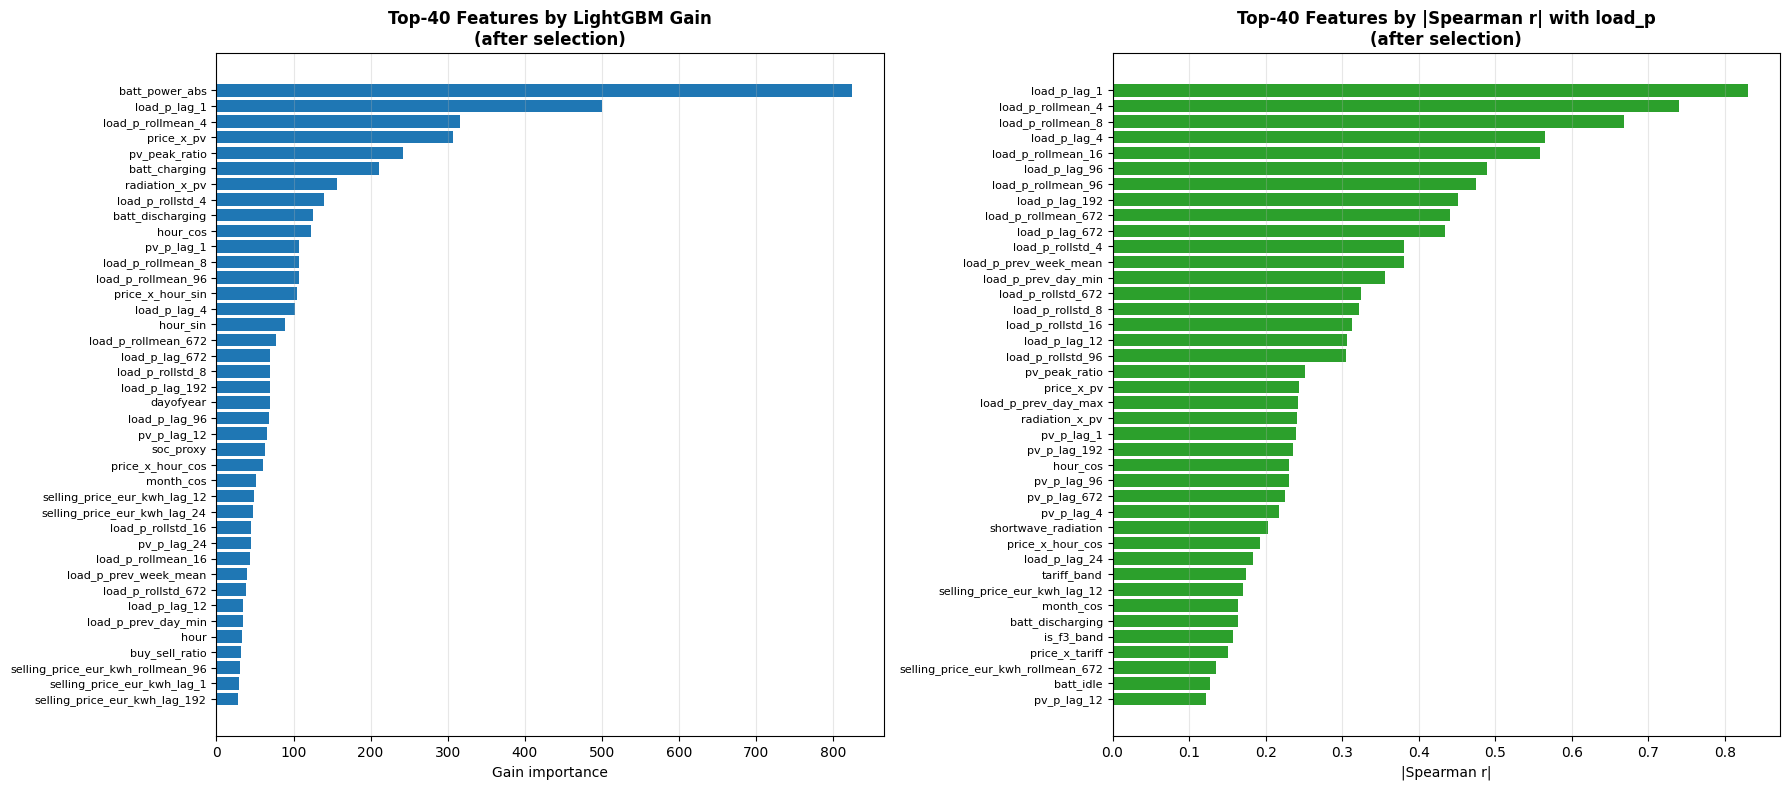


Saved: feature_selection_summary.csv, feature_cols.json
            feature     variance  spearman_r  lgbm_gain
     batt_power_abs       0.9163      0.0503        825
       load_p_lag_1       1.5614      0.8304        500
  load_p_rollmean_4       1.2572      0.7399        316
         price_x_pv       0.0300      0.2438        307
      pv_peak_ratio       0.0985      0.2517        242
      batt_charging       0.1615      0.0424        211
     radiation_x_pv 1465411.5918      0.2411        156
   load_p_rollstd_4       0.1918      0.3814        139
   batt_discharging       0.2358      0.1639        125
           hour_cos       0.5000      0.2305        123
         pv_p_lag_1       3.2664      0.2398        107
  load_p_rollmean_8       1.0759      0.6675        107
 load_p_rollmean_96       0.3478      0.4750        107
   price_x_hour_sin       0.0067      0.0418        105
       load_p_lag_4       1.5616      0.5652        102
           hour_sin       0.5000      0.0456   

In [20]:
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import spearmanr

def select_features(df_train, feature_cols, target=None,
                    corr_threshold=0.02,
                    importance_threshold=0,
                    variance_threshold=1e-6):
    """
    Three-stage feature selection:
      1. Variance filter   — drop near-constant columns
      2. Correlation filter — drop features with |Spearman r| < corr_threshold vs target
      3. Importance filter — fit a fast LightGBM, drop zero-gain features

    Returns the filtered feature list and a summary DataFrame.
    """
    if target is None: target = LOAD_COL

    clean = df_train[feature_cols + [target]].dropna()
    X = clean[feature_cols]
    y = clean[target]

    # ── Stage 1: Variance filter ──────────────────────────────────────────────
    sel = VarianceThreshold(threshold=variance_threshold)
    sel.fit(X)
    keep_var = [f for f, v in zip(feature_cols, sel.variances_) if v > variance_threshold]
    dropped_var = set(feature_cols) - set(keep_var)
    print(f'[1] Variance filter  : {len(dropped_var):3d} dropped, {len(keep_var)} remain')

    # ── Stage 2: Spearman correlation filter ──────────────────────────────────
    corrs = {}
    for col in keep_var:
        r, _ = spearmanr(X[col].fillna(0), y)
        corrs[col] = abs(r)
    keep_corr = [f for f in keep_var if corrs.get(f, 0) >= corr_threshold]
    dropped_corr = set(keep_var) - set(keep_corr)
    print(f'[2] Correlation filter: {len(dropped_corr):3d} dropped (|r| < {corr_threshold}), {len(keep_corr)} remain')

    # ── Stage 3: LightGBM gain importance filter ──────────────────────────────
    quick_params = dict(n_estimators=200, max_depth=5, num_leaves=63,
                        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                        reg_lambda=5.0, min_child_samples=50,
                        random_state=42, n_jobs=-1, verbose=-1)
    scout = lgb.LGBMRegressor(**quick_params)
    scout.fit(X[keep_corr].fillna(0), np.log1p(y),
              categorical_feature=['tariff_band'] if 'tariff_band' in keep_corr else 'auto')

    imp = dict(zip(keep_corr, scout.feature_importances_))
    keep_imp = [f for f in keep_corr if imp.get(f, 0) > importance_threshold]
    dropped_imp = set(keep_corr) - set(keep_imp)
    print(f'[3] Importance filter : {len(dropped_imp):3d} dropped (gain = 0), {len(keep_imp)} remain')

    # ── Summary table ─────────────────────────────────────────────────────────
    summary = pd.DataFrame({
        'feature'   : keep_imp,
        'variance'  : [sel.variances_[feature_cols.index(f)] for f in keep_imp],
        'spearman_r': [corrs[f] for f in keep_imp],
        'lgbm_gain' : [imp[f] for f in keep_imp],
    }).sort_values('lgbm_gain', ascending=False).reset_index(drop=True)

    return keep_imp, summary

# ── Run feature selection ──────────────────────────────────────────────────────
print('Running feature selection…')
FEATURE_COLS, feat_summary = select_features(
    df_2024_feat, FEATURE_COLS,
    corr_threshold=0.02,
    importance_threshold=0,
    variance_threshold=1e-6
)
print(f'\nFinal selected features: {len(FEATURE_COLS)}')

# ── Plot: top-40 gain importances ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top-40 gain bar
top40 = feat_summary.head(40)
axes[0].barh(top40['feature'][::-1], top40['lgbm_gain'][::-1], color='#1f77b4')
axes[0].set_title('Top-40 Features by LightGBM Gain\n(after selection)', fontweight='bold')
axes[0].set_xlabel('Gain importance')
axes[0].tick_params(axis='y', labelsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Spearman correlation bar (top 40)
top40_corr = feat_summary.sort_values('spearman_r', ascending=False).head(40)
axes[1].barh(top40_corr['feature'][::-1], top40_corr['spearman_r'][::-1], color='#2ca02c')
axes[1].set_title('Top-40 Features by |Spearman r| with load_p\n(after selection)', fontweight='bold')
axes[1].set_xlabel('|Spearman r|')
axes[1].tick_params(axis='y', labelsize=8)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('results/plots/feature_selection.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Save ──────────────────────────────────────────────────────────────────────
feat_summary.to_csv(f'{MODELS_DIR}/feature_selection_summary.csv', index=False)
with open(f'{MODELS_DIR}/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
print(f'\nSaved: feature_selection_summary.csv, feature_cols.json')
print(feat_summary.head(20).to_string(index=False))


### 4j. Leakage Self-Tests

In [21]:
def test_no_leakage(df, target=None):
    if target is None: target = LOAD_COL
    # We check the 672 lag specifically since it's the minimum in your set
    lag_val = 672
    lag_col = f'{target}_lag_{lag_val}'
    
    # Use an index (1000) where this lag is guaranteed to be populated
    idx = 1000 
    actual   = df[lag_col].iloc[idx]
    expected = df[target].iloc[idx - lag_val]
    
    assert np.isclose(actual, expected, equal_nan=True), (
        f'LEAKAGE ERROR: {lag_col}[{idx}]={actual:.4f} != {target}[{idx-lag_val}]={expected:.4f}')
    print(f'✓ No leakage: {lag_col}[{idx}]={actual:.4f} == {target}[{idx-lag_val}]={expected:.4f}')

def test_quantile_no_leakage(df_train, df_test, cap, col):
    ok = (df_test[col] <= cap + 1e-9).all()
    assert ok, f'Test values of {col} exceed train cap — leakage?'
    print(f'✓ {col} cap ({cap:.4f}) correctly applied to test set.')

test_no_leakage(df_2024_feat)
test_no_leakage(df_2025_feat)
test_quantile_no_leakage(df_2024_feat, df_2025_feat, LOAD_CAP, LOAD_COL)
test_quantile_no_leakage(df_2024_feat, df_2025_feat, PRICE_CAP, PRICE_COL)
print('\nAll leakage tests passed ')

✓ No leakage: load_p_lag_672[1000]=2.5800 == load_p[328]=2.5800
✓ No leakage: load_p_lag_672[1000]=2.8800 == load_p[328]=2.8800
✓ load_p cap (6.2100) correctly applied to test set.
✓ selling_price_eur_kwh cap (0.2526) correctly applied to test set.

All leakage tests passed 


In [22]:
def safe_mape(y_true, y_pred, threshold=0.1):
    """MAPE only on timesteps where actual load > threshold kW.
    Near-zero actual values (night standby) cause MAPE to blow up to millions %.
    threshold=0.1 kW is a safe minimum — below this the percentage is meaningless."""
    mask = np.abs(y_true) > threshold
    if mask.sum() == 0:
        return np.nan
    return float((np.abs(np.array(y_pred)[mask] - np.array(y_true)[mask])
                  / np.abs(np.array(y_true)[mask])).mean() * 100)

def calculate_nrmse(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse / (y_true.max() - y_true.min() + 1e-9)

def optuna_objective(trial, df_train, feature_cols, target=None, n_folds=3):
    """
    Time-series walk-forward CV for Optuna.
    Tightened search space to prevent overfitting:
      - num_leaves capped at 127 (was 255)
      - max_depth capped at 7   (was 12)
      - min_child_samples raised floor to 50 (was 10)
      - reg_lambda floor raised to 1.0 (was 0.0001)
    """
    if target is None: target = LOAD_COL

    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 1500),
        'max_depth'        : trial.suggest_int('max_depth', 4, 7),
        'num_leaves'       : trial.suggest_int('num_leaves', 31, 127),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'subsample_freq'   : 1,
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1.0, 20.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 50, 200),
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbose'          : -1,
    }

    clean = df_train[feature_cols + [target]].dropna()
    n = len(clean)
    fold_size = n // (n_folds + 1)

    rmses = []
    for fold in range(n_folds):
        train_end = fold_size * (fold + 1)
        val_end   = train_end + fold_size
        X_tr = clean[feature_cols].iloc[:train_end]
        y_tr = np.log1p(clean[target].iloc[:train_end])
        X_vl = clean[feature_cols].iloc[train_end:val_end]
        y_vl = clean[target].iloc[train_end:val_end]
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_vl, np.log1p(y_vl))],
            eval_metric='rmse',
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(-1)],
            categorical_feature=['tariff_band'] if 'tariff_band' in feature_cols else 'auto',
        )
        y_pred = np.expm1(model.predict(X_vl, num_iteration=model.best_iteration_))
        y_pred = np.maximum(0, y_pred)
        rmses.append(np.sqrt(mean_squared_error(y_vl, y_pred)))

    return float(np.mean(rmses))

print(f'Running Optuna search ({OPTUNA_TRIALS} trials, 3-fold walk-forward CV)…')
study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(
    lambda trial: optuna_objective(trial, df_2024_feat, FEATURE_COLS),
    n_trials=OPTUNA_TRIALS,
    show_progress_bar=True,
)

BEST_PARAMS = study.best_params
BEST_PARAMS.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})
print(f'\nBest RMSE (log-space, CV): {study.best_value:.4f}')
print('Best params:')
for k, v in BEST_PARAMS.items():
    print(f'  {k}: {v}')

with open(f'{MODELS_DIR}/best_params.json', 'w') as f:
    json.dump(BEST_PARAMS, f, indent=2)
print('\nbest_params.json saved.')


Running Optuna search (50 trials, 3-fold walk-forward CV)…


  0%|          | 0/50 [00:00<?, ?it/s]


Best RMSE (log-space, CV): 0.5997
Best params:
  n_estimators: 1471
  max_depth: 6
  num_leaves: 66
  learning_rate: 0.06102765873258985
  subsample: 0.849333652382448
  colsample_bytree: 0.9501945220447685
  reg_alpha: 0.474674333352544
  reg_lambda: 5.497962602751295
  min_child_samples: 156
  random_state: 42
  n_jobs: -1
  verbose: -1

best_params.json saved.


## Section 5: Optuna Hyperparameter Search

Uses **time-series cross-validation** (walk-forward, 3 folds) to avoid leakage.
The objective minimises RMSE on the validation fold after log1p transform.


## Section 6: Recursive Forecast Loop (v3)

Key improvements over v2:
- **log1p transform** on target during training; `expm1` on output
- **Best Optuna params** used
- **7-day warm-up** (672 steps) ensures lag_672 is fully populated from step 0
- **Selling price lags updated** in the loop using known future values (selling price is known at time of dispatch — it's the realised grid price, not a forecast)
- Momentum features rebuilt at each step


In [23]:
def run_recursive_forecast_v3(df_train, df_test, feature_cols,
                               best_params=None, target=None,
                               val_size=0.15):
    """
    Recursive 2025 forecast — fully leak-free at inference time.

    Guarantees:
      - WARMUP = max(LAG_STEPS): no negative-index wrapping
      - Lags updated BEFORE predict(), prediction written AFTER
      - Rolling stats rebuilt from running predicted buffer
      - Prediction floor = 1st percentile of training load (no hard-zero collapse)
      - MAPE computed only on actual > 0.1 kW (avoids near-zero explosion)
    """
    if target is None: target = LOAD_COL
    if best_params is None: best_params = BEST_PARAMS

    # Load floor: 1st percentile of training set — prevents night-time collapse to 0
    LOAD_FLOOR = float(np.percentile(df_train[target].dropna(), 1))
    print(f'Load floor (1st pct of train): {LOAD_FLOOR:.4f} kW')

    # ── 1. Temporal split ──────────────────────────────────────────────────────
    split_idx = int(len(df_train) * (1 - val_size))
    d_tr = df_train.iloc[:split_idx].copy()
    d_vl = df_train.iloc[split_idx:].copy()

    X_tr = d_tr[feature_cols].fillna(0)
    y_tr = np.log1p(d_tr[target])
    X_vl = d_vl[feature_cols].fillna(0)
    y_vl = np.log1p(d_vl[target])

    # ── 2. Train ───────────────────────────────────────────────────────────────
    model = lgb.LGBMRegressor(**best_params)
    cat_feats = ['tariff_band'] if 'tariff_band' in feature_cols else 'auto'
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_vl, y_vl)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False),
                   lgb.log_evaluation(period=200)],
        categorical_feature=cat_feats if isinstance(cat_feats, list) else 'auto',
    )
    print(f'✓ Trained on {len(X_tr):,} rows | Best iteration: {model.best_iteration_}')

    # ── 3. Build combined buffer ───────────────────────────────────────────────
    WARMUP = max(LAG_STEPS)
    tail_train     = df_train.tail(WARMUP).copy()
    combined       = pd.concat([tail_train, df_test.copy()]).copy()
    col_idx        = {c: combined.columns.get_loc(c) for c in combined.columns}
    target_col_pos = col_idx[target]

    load_lag_map  = {f'{target}_lag_{s}': s for s in LAG_STEPS if f'{target}_lag_{s}' in col_idx}
    pv_lag_map    = {f'{PV_COL}_lag_{s}': s for s in LAG_STEPS if f'{PV_COL}_lag_{s}' in col_idx}
    price_lag_map = {f'{PRICE_COL}_lag_{s}': s for s in LAG_STEPS if f'{PRICE_COL}_lag_{s}' in col_idx}
    roll_mean_map = {f'{target}_rollmean_{w}': w for w in [4, 8, 16, 96, 192, 672]
                     if f'{target}_rollmean_{w}' in feature_cols and f'{target}_rollmean_{w}' in col_idx}
    roll_std_map  = {f'{target}_rollstd_{w}': w for w in [4, 8, 16, 96, 192, 672]
                     if f'{target}_rollstd_{w}' in feature_cols and f'{target}_rollstd_{w}' in col_idx}

    preds = {}
    print(f'Starting recursive forecast ({len(combined)-WARMUP:,} steps, WARMUP={WARMUP})…')

    for i in range(WARMUP, len(combined)):

        # A: update load lags from running buffer (past predictions/real data)
        for lag_col, shift in load_lag_map.items():
            combined.iloc[i, col_idx[lag_col]] = combined.iloc[i - shift, target_col_pos]

        # B: update exogenous lags (PV and price use actual values)
        for lag_col, shift in pv_lag_map.items():
            combined.iloc[i, col_idx[lag_col]] = combined.iloc[i - shift][PV_COL]
        for lag_col, shift in price_lag_map.items():
            src_i = i - shift
            if src_i >= 0:
                combined.iloc[i, col_idx[lag_col]] = combined.iloc[src_i][PRICE_COL]

        # C: rebuild rolling stats from updated buffer (reads i-1 backwards, never i)
        for col_name, w in roll_mean_map.items():
            vals = [combined.iloc[i - k, target_col_pos] for k in range(1, w + 1) if i - k >= 0]
            combined.iloc[i, col_idx[col_name]] = np.mean(vals) if vals else 0.0
        for col_name, w in roll_std_map.items():
            vals = [combined.iloc[i - k, target_col_pos] for k in range(1, w + 1) if i - k >= 0]
            combined.iloc[i, col_idx[col_name]] = np.std(vals) if len(vals) > 1 else 0.0

        # D: predict
        row = combined.iloc[[i]][feature_cols].fillna(0)
        log_pred = float(model.predict(row, num_iteration=model.best_iteration_)[0])
        pred = max(LOAD_FLOOR, float(np.expm1(log_pred)))   # floor, not hard zero

        # E: write prediction AFTER predict() — never feeds into its own features
        combined.iloc[i, target_col_pos] = pred
        preds[combined.index[i]] = pred

    forecast_series = pd.Series(preds, name=f'{target}_forecast')
    print(f'✓ Forecast complete: {len(forecast_series):,} steps')
    print(f'   Mean={forecast_series.mean():.3f}  Std={forecast_series.std():.3f}  '
          f'Min={forecast_series.min():.3f}  Max={forecast_series.max():.3f}')

    # ── 4. Metrics ─────────────────────────────────────────────────────────────
    eval_df = pd.DataFrame({'actual': df_test[target], 'pred': forecast_series}).dropna()
    for label, months in [('April + September', [4, 9]), ('Full 2025', list(range(1, 13)))]:
        sub = eval_df[eval_df.index.month.isin(months)]
        if sub.empty: continue
        yt, yp = sub['actual'].values, sub['pred'].values
        mae   = mean_absolute_error(yt, yp)
        rmse  = np.sqrt(mean_squared_error(yt, yp))
        nrmse = rmse / (yt.max() - yt.min() + 1e-9)
        mape  = safe_mape(yt, yp, threshold=0.1)
        print(f'\n── {label} ──')
        print(f'   MAE   : {mae:.4f} kW')
        print(f'   MAPE  : {mape:.2f} % (on actual > 0.1 kW)')
        print(f'   RMSE  : {rmse:.4f} kW')
        print(f'   NRMSE : {nrmse:.4f} ({nrmse:.2%})')

    return model, forecast_series

model_load, forecasts_2025 = run_recursive_forecast_v3(
    df_2024_feat, df_2025_feat, FEATURE_COLS
)


Load floor (1st pct of train): 0.1200 kW
[200]	training's rmse: 0.1604	training's l2: 0.0257281	valid_1's rmse: 0.28051	valid_1's l2: 0.0786856
✓ Trained on 29,865 rows | Best iteration: 263
Starting recursive forecast (34,945 steps, WARMUP=672)…
✓ Forecast complete: 34,945 steps
   Mean=1.342  Std=0.989  Min=0.120  Max=6.107

── April + September ──
   MAE   : 0.3305 kW
   MAPE  : 65.75 % (on actual > 0.1 kW)
   RMSE  : 0.6389 kW
   NRMSE : 0.1076 (10.76%)

── Full 2025 ──
   MAE   : 0.5726 kW
   MAPE  : 72.57 % (on actual > 0.1 kW)
   RMSE  : 0.9484 kW
   NRMSE : 0.1527 (15.27%)


## Section 7: QA Plots

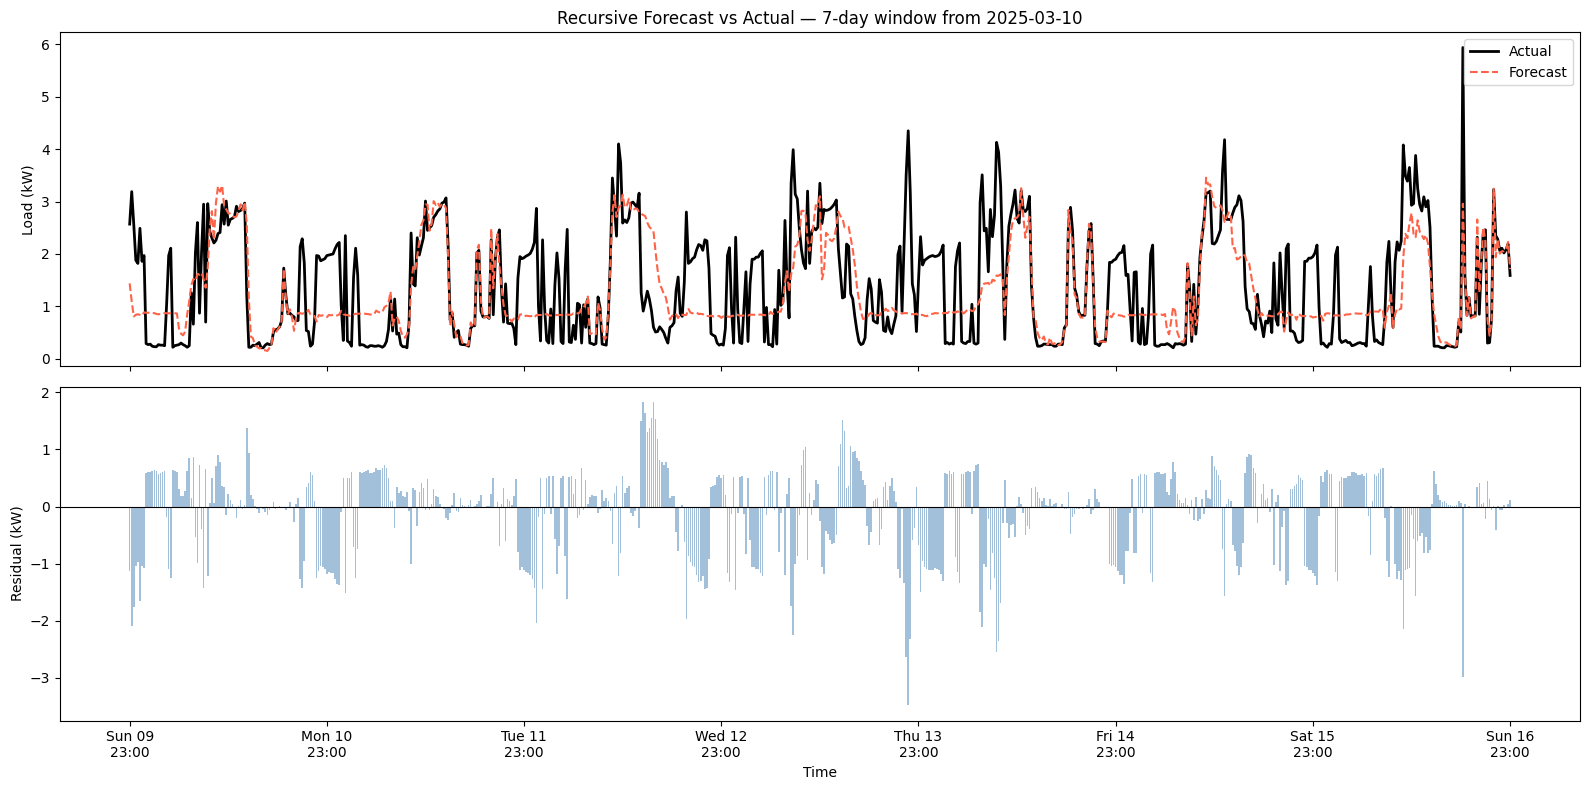

Residual stats: mean=-0.125, std=0.748, mae=0.564


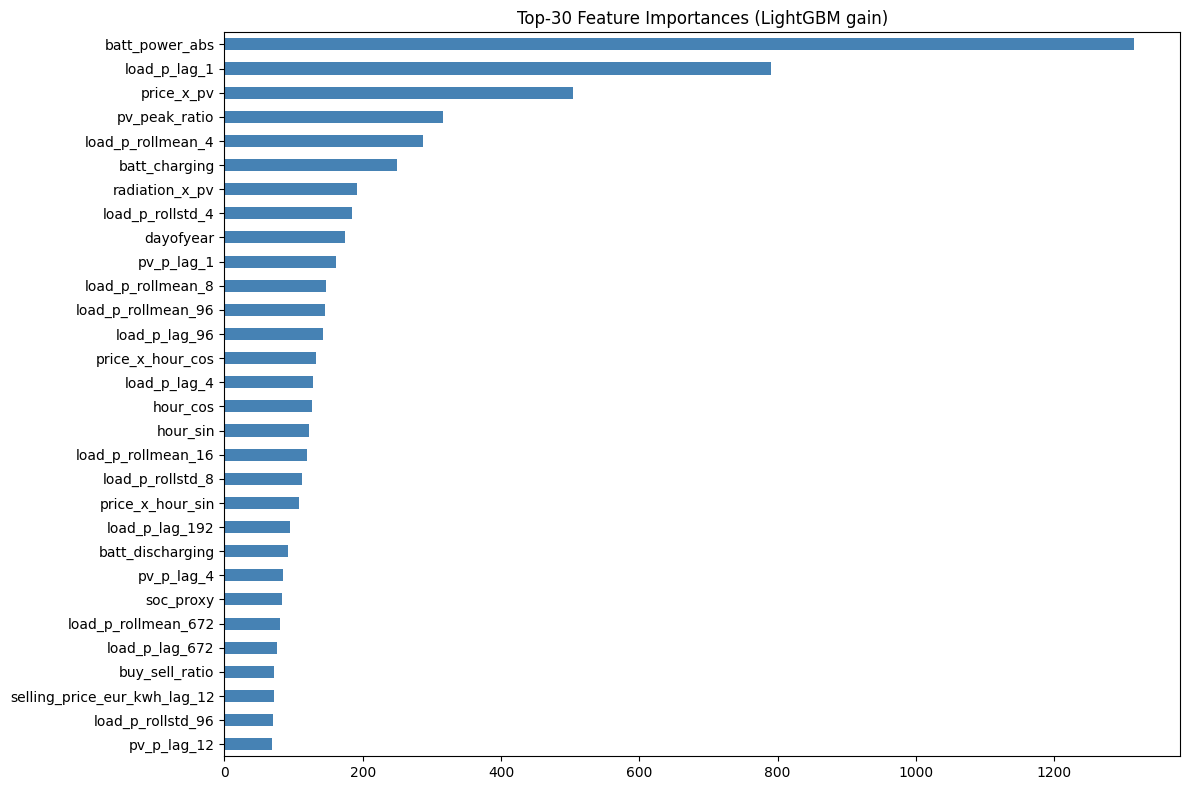


Top-10 features:
batt_power_abs       1316
load_p_lag_1          791
price_x_pv            504
pv_peak_ratio         316
load_p_rollmean_4     287
batt_charging         249
radiation_x_pv        192
load_p_rollstd_4      185
dayofyear             174
pv_p_lag_1            162


In [24]:
def plot_forecast_vs_actual(df_test, forecast, label='2025-03-10', days=7):
    start = pd.Timestamp(label, tz='Europe/Rome')
    end   = start + pd.Timedelta(days=days)
    sl    = slice(start, end)

    actual = df_test.loc[sl, LOAD_COL]
    pred   = forecast.loc[sl]

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    # Top: forecast vs actual
    axes[0].plot(actual.index, actual.values, lw=2, color='black', label='Actual')
    axes[0].plot(pred.index,   pred.values,   lw=1.5, color='tomato',
                 linestyle='--', label='Forecast')
    axes[0].set_ylabel('Load (kW)')
    axes[0].set_title(f'Recursive Forecast vs Actual — {days}-day window from {label}')
    axes[0].legend()

    # Bottom: residuals
    residual = pred - actual
    axes[1].bar(residual.index, residual.values, color='steelblue', alpha=0.5, width=0.008)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_ylabel('Residual (kW)')
    axes[1].set_xlabel('Time')

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d\n%H:%M'))
    plt.tight_layout()
    plt.savefig('results/plots/forecast_vs_actual.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Residual stats: mean={residual.mean():.3f}, std={residual.std():.3f}, '
          f'mae={residual.abs().mean():.3f}')

plot_forecast_vs_actual(df_2025_feat, forecasts_2025)

# ── Feature importance ────────────────────────────────────────────────────
fi = pd.Series(model_load.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 8))
fi.head(30).plot.barh(ax=ax, color='steelblue')
ax.set_title('Top-30 Feature Importances (LightGBM gain)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('results/plots/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nTop-10 features:')
print(fi.head(10).to_string())


Found sets: ['training', 'valid_1']
Found metric: rmse


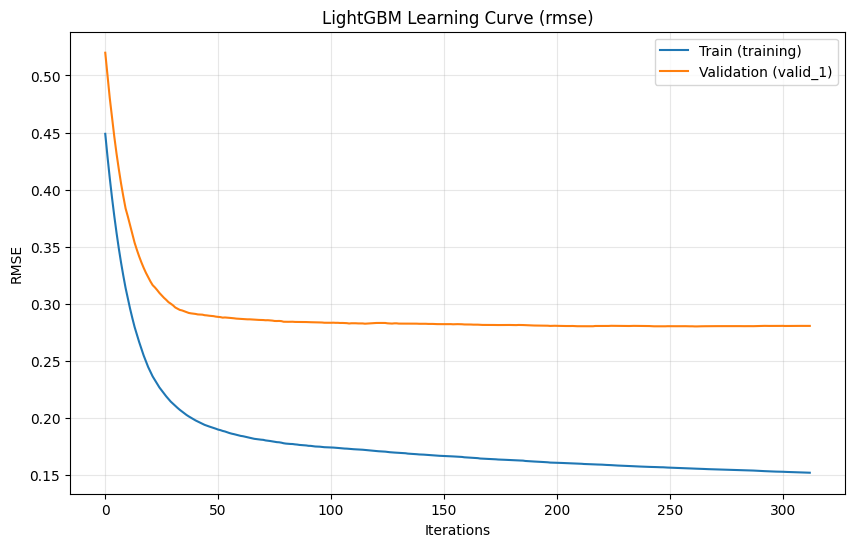

In [25]:
import matplotlib.pyplot as plt

def plot_learning_curves(model):
    # 1. Check if model has the attribute
    if not hasattr(model, 'evals_result_'):
        print("Error: This model object does not have training history.")
        print("Note: History is lost when you save/load a model. You must plot right after training.")
        return

    results = model.evals_result_
    keys = list(results.keys())
    
    # 2. Check if the history dictionary is empty
    if not keys:
        print("Error: The training history is empty.")
        print("Make sure you passed 'eval_set' during the .fit() or .train() process.")
        return

    plt.figure(figsize=(10, 6))
    
    # 3. Dynamically find the metric name (e.g., 'rmse', 'l2', 'rmse-mean')
    # We take the first metric found in the first available set
    first_set = keys[0]
    metrics = list(results[first_set].keys())
    metric_name = metrics[0] # Usually 'rmse' in your case
    
    print(f"Found sets: {keys}")
    print(f"Found metric: {metric_name}")

    # 4. Plot based on available keys
    for i, set_name in enumerate(keys):
        label = 'Train' if i == 0 else 'Validation'
        plt.plot(results[set_name][metric_name], label=f"{label} ({set_name})")
    
    plt.title(f'LightGBM Learning Curve ({metric_name})')
    plt.xlabel('Iterations')
    plt.ylabel(metric_name.upper())
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the fixed function
plot_learning_curves(model_load)

In [26]:
def calculate_gen_gap_robust(model):
    if not hasattr(model, 'evals_result_') or not model.evals_result_:
        return "No training history found."
    
    res = model.evals_result_
    keys = list(res.keys())
    metric = list(res[keys[0]].keys())[0]
    
    if len(keys) < 2:
        return "Only one eval_set found. Training and Validation sets are both required for a gap analysis."
    
    train_loss = res[keys[0]][metric][-1]
    valid_loss = res[keys[1]][metric][-1]
    gap = valid_loss - train_loss
    
    print(f"Metric: {metric}")
    print(f"Train:  {train_loss:.4f}")
    print(f"Valid:  {valid_loss:.4f}")
    print(f"Gap:    {gap:.4f} ({(gap/train_loss)*100:.2f}%)")

calculate_gen_gap_robust(model_load)

Metric: rmse
Train:  0.1516
Valid:  0.2804
Gap:    0.1288 (84.93%)


In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def print_final_metrics(y_true_log, y_pred_log, label="Validation"):
    # Convert back from log to original scale (kW)
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    
    # Ensure no negative values
    y_pred = np.maximum(0, y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Normalized RMSE
    nrmse = rmse / (y_true.max() - y_true.min() + 1e-9)

    print(f"--- {label} Results (Original Scale - kW) ---")
    print(f"RMSE:  {rmse:.4f}")
    print(f"MAE:   {mae:.4f}")
    print(f"NRMSE: {nrmse:.2%}")
    print(f"R²:    {r2:.4f}")

# Example Usage:
# y_pred_log = model_load.predict(X_vl)
# print_final_metrics(y_vl, y_pred_log)

## Section 8: Save Outputs

In [28]:
# Save forecast
forecasts_2025.to_csv(f'{MODELS_DIR}/forecasts_2025.csv', header=True)

# Save model
model_load.booster_.save_model(f'{MODELS_DIR}/lgbm_load_model.txt')

# Save feature importance
fi_df = pd.DataFrame({'feature': FEATURE_COLS,
                       'importance': model_load.feature_importances_})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)
fi_df.to_csv(f'{MODELS_DIR}/feature_importance.csv', index=False)

print('Saved:')
print(f'  {MODELS_DIR}/forecasts_2025.csv')
print(f'  {MODELS_DIR}/lgbm_load_model.txt')
print(f'  {MODELS_DIR}/feature_importance.csv')
print(f'  {MODELS_DIR}/best_params.json')
print(f'  {MODELS_DIR}/train_stats.json')
print('\n✅ Pipeline complete.')


Saved:
  models/forecasts_2025.csv
  models/lgbm_load_model.txt
  models/feature_importance.csv
  models/best_params.json
  models/train_stats.json

✅ Pipeline complete.


## Section 9: Excel Report & Diagnostic Plots

Generates:
- **`forecast_report.xlsx`** — three sheets: Forecast vs Actual (all 15-min rows), Error Metrics (overall + monthly MAE/MAPE/RMSE/NRMSE), Monthly Charts (embedded bar + line charts)
- **`forecast_diagnostics.png`** — 6-panel figure: full-year overlay, error time-series, monthly RMSE bar, error histogram, abs-error histogram, APE histogram

✓ Excel workbook saved: models/forecast_report.xlsx
  Sheets: Forecast vs Actual (34,945 rows) | Error Metrics | Monthly Charts


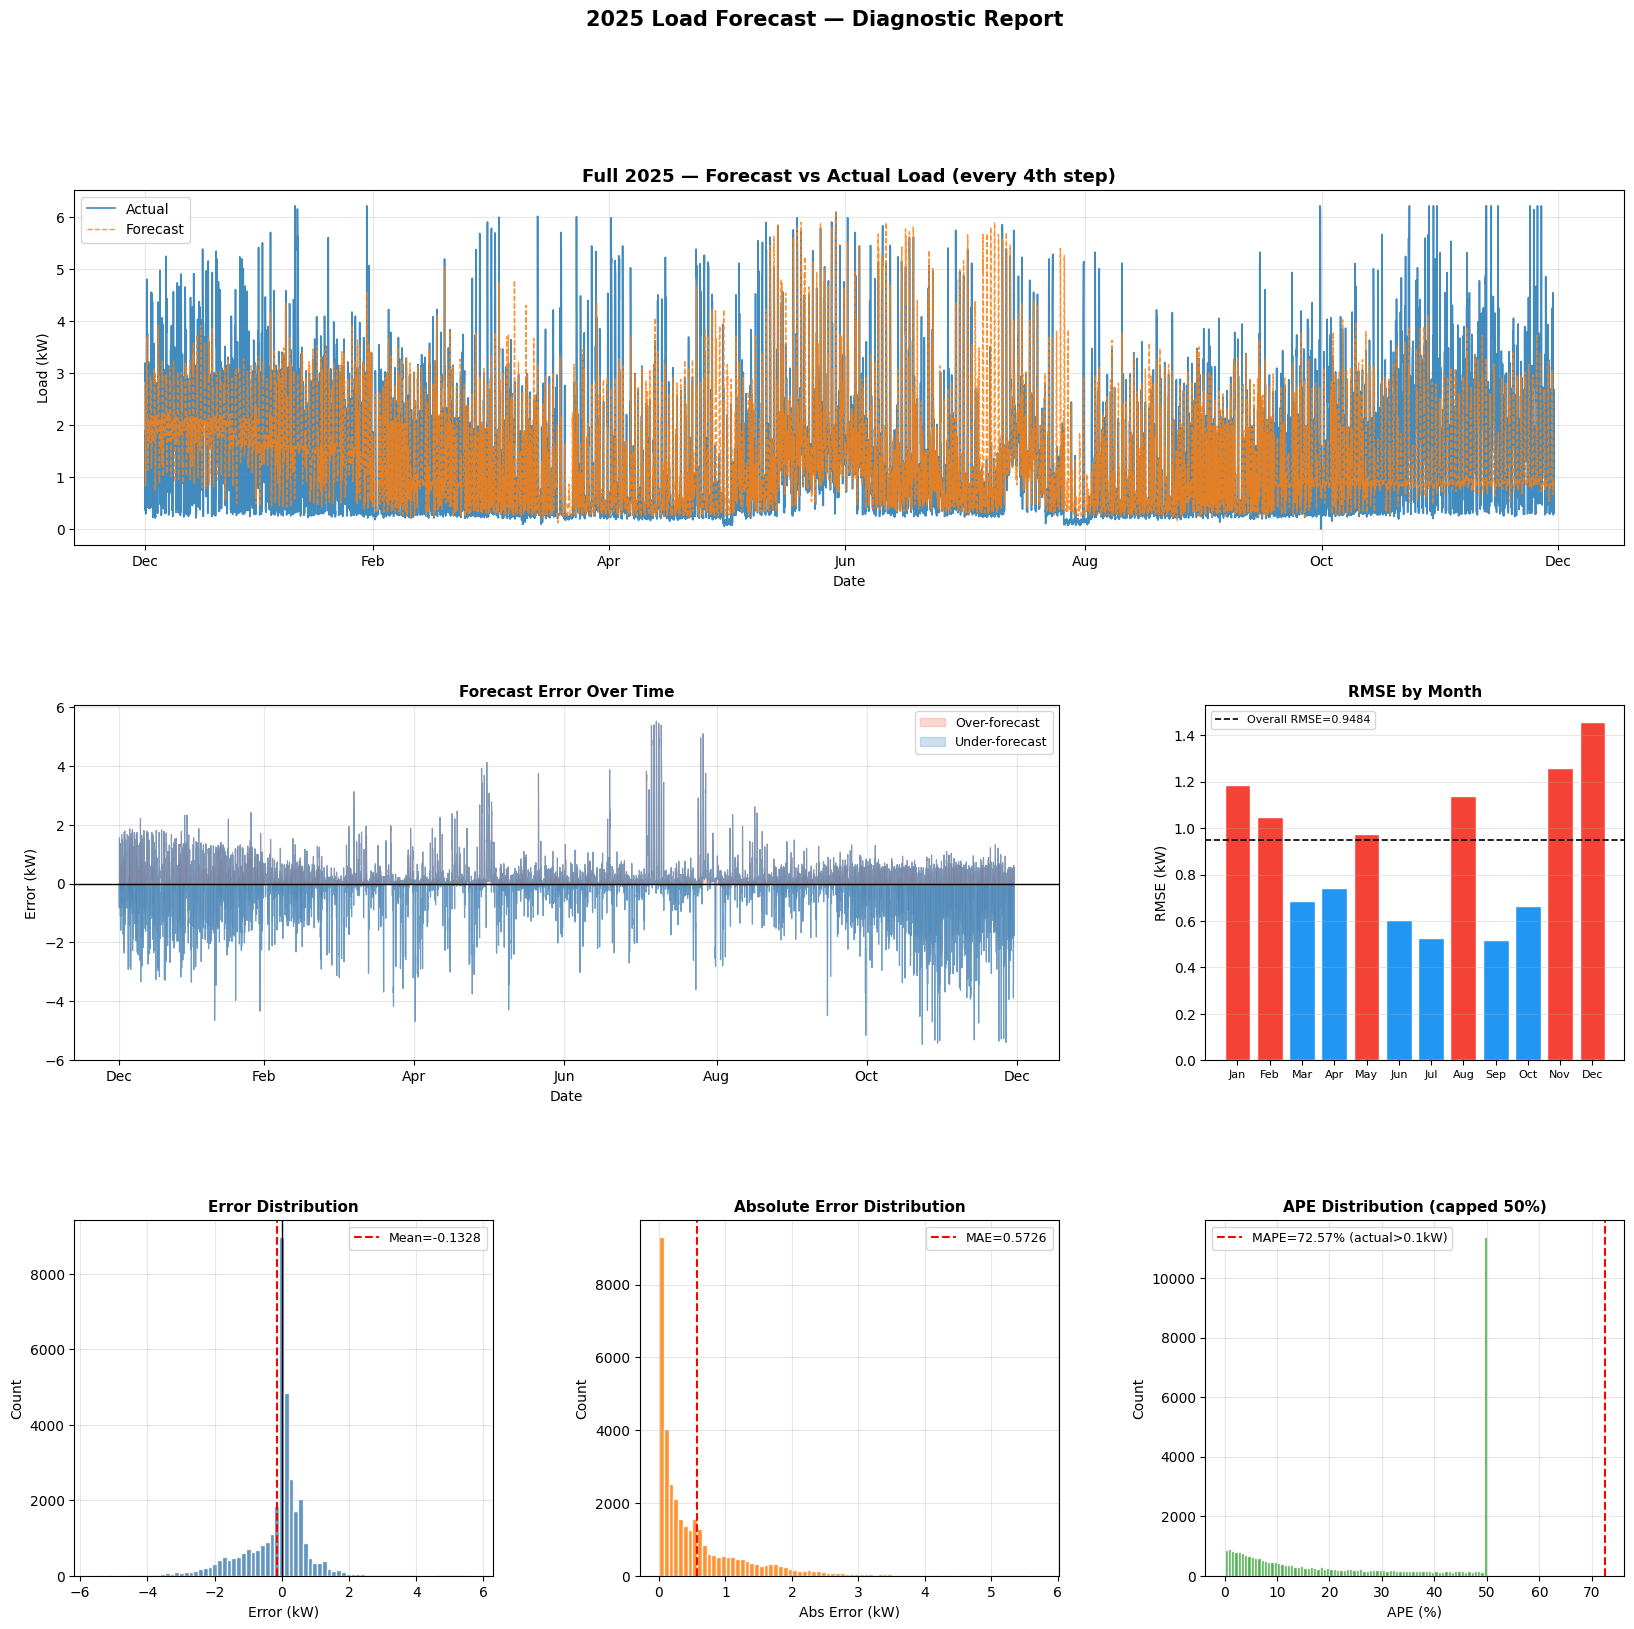

✓ Diagnostic figure saved: results/plots/forecast_diagnostics.png

── Metrics Summary ──
        Period  MAE (kW)  MAPE (%)  RMSE (kW)  NRMSE
     Full 2025    0.5726   72.5745     0.9484 0.1527
  January 2025    0.9488   97.7879     1.1858 0.1973
 February 2025    0.8144   96.2029     1.0497 0.1750
    March 2025    0.4267   51.5286     0.6843 0.1170
    April 2025    0.3779   65.3483     0.7411 0.1252
      May 2025    0.5212  103.6898     0.9737 0.1581
     June 2025    0.3304   40.0880     0.6063 0.1004
     July 2025    0.2801   27.2949     0.5275 0.0866
   August 2025    0.5255  136.9325     1.1381 0.1900
September 2025    0.2832   66.1591     0.5168 0.0928
  October 2025    0.3820   54.5986     0.6638 0.1069
 November 2025    0.8893   65.6646     1.2567 0.2070
 December 2025    1.1197   68.0387     1.4569 0.2428


In [29]:
# ── Section 9: Excel Report + Diagnostic Plots ───────────────────────────────
import openpyxl
from openpyxl.styles import (Font, PatternFill, Alignment, Border, Side,
                              numbers as xl_numbers)
from openpyxl.utils import get_column_letter
from openpyxl.chart import BarChart, LineChart, Reference
from openpyxl.chart.series import DataPoint
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── 1. Build evaluation DataFrame ─────────────────────────────────────────────
eval_df = pd.DataFrame({
    'timestamp'  : df_2025_feat.index,
    'actual_kw'  : df_2025_feat[LOAD_COL].values,
    'forecast_kw': forecasts_2025.reindex(df_2025_feat.index).values,
}).dropna()

eval_df['error']     = eval_df['forecast_kw'] - eval_df['actual_kw']
eval_df['abs_error'] = eval_df['error'].abs()
# APE only where actual > 0.1 kW — below this MAPE is numerically meaningless
eval_df['pct_error'] = np.where(
    eval_df['actual_kw'] > 0.1,
    eval_df['abs_error'] / eval_df['actual_kw'] * 100,
    np.nan
)

# ── 2. Overall + monthly metrics ──────────────────────────────────────────────
def metrics_dict(sub, label):
    yt, yp = sub['actual_kw'], sub['forecast_kw']
    rmse  = float(np.sqrt(mean_squared_error(yt, yp)))
    mae   = float(mean_absolute_error(yt, yp))
    mape  = safe_mape(yt.values, yp.values, threshold=0.1)
    nrmse = rmse / float(yt.max() - yt.min() + 1e-9)
    return {'Period': label, 'MAE (kW)': mae, 'MAPE (%)': mape,
            'RMSE (kW)': rmse, 'NRMSE': nrmse}

rows = [metrics_dict(eval_df, 'Full 2025')]
for m in range(1, 13):
    sub = eval_df[eval_df['timestamp'].dt.month == m]
    if not sub.empty:
        rows.append(metrics_dict(sub, sub['timestamp'].dt.strftime('%B %Y').iloc[0]))
metrics_df = pd.DataFrame(rows)

# ── 3. Build Excel workbook ────────────────────────────────────────────────────
wb = openpyxl.Workbook()

# ── Styles ────────────────────────────────────────────────────────────────────
HDR_FILL   = PatternFill('solid', start_color='1F4E79')
HDR_FONT   = Font(bold=True, color='FFFFFF', name='Arial', size=10)
ALT_FILL   = PatternFill('solid', start_color='D9E1F2')
PLAIN_FILL = PatternFill('solid', start_color='FFFFFF')
TOTAL_FILL = PatternFill('solid', start_color='FCE4D6')
TOTAL_FONT = Font(bold=True, name='Arial', size=10)
BODY_FONT  = Font(name='Arial', size=9)
CENTER     = Alignment(horizontal='center', vertical='center', wrap_text=False)
thin       = Side(style='thin', color='BFBFBF')
BORDER     = Border(left=thin, right=thin, top=thin, bottom=thin)

NUM_FMT_2  = '0.0000'
NUM_FMT_PCT= '0.00%'

def style_header(cell, fill=HDR_FILL, font=HDR_FONT):
    cell.fill, cell.font, cell.alignment, cell.border = fill, font, CENTER, BORDER

def style_body(cell, alt=False, bold=False):
    cell.fill  = ALT_FILL if alt else PLAIN_FILL
    cell.font  = Font(bold=bold, name='Arial', size=9)
    cell.alignment = Alignment(horizontal='center', vertical='center')
    cell.border = BORDER

# ─── Sheet 1: Forecast vs Actual ─────────────────────────────────────────────
ws1 = wb.active
ws1.title = 'Forecast vs Actual'
ws1.freeze_panes = 'A2'

headers1 = ['Timestamp', 'Actual (kW)', 'Forecast (kW)', 'Error (kW)',
            'Abs Error (kW)', 'APE (%)']
for c, h in enumerate(headers1, 1):
    cell = ws1.cell(1, c, h)
    style_header(cell)

col_widths1 = [22, 14, 14, 13, 15, 10]
for c, w in enumerate(col_widths1, 1):
    ws1.column_dimensions[get_column_letter(c)].width = w

for r, row in enumerate(eval_df.itertuples(index=False), 2):
    alt = (r % 2 == 0)
    ts_str = row.timestamp.strftime('%Y-%m-%d %H:%M') if hasattr(row.timestamp, 'strftime') else str(row.timestamp)
    vals = [ts_str, row.actual_kw, row.forecast_kw, row.error, row.abs_error, row.pct_error / 100]
    fmts = [None, NUM_FMT_2, NUM_FMT_2, NUM_FMT_2, NUM_FMT_2, '0.00%']
    for c, (v, fmt) in enumerate(zip(vals, fmts), 1):
        cell = ws1.cell(r, c, v)
        style_body(cell, alt)
        if fmt:
            cell.number_format = fmt

ws1.auto_filter.ref = f'A1:{get_column_letter(len(headers1))}1'

# ─── Sheet 2: Error Metrics ───────────────────────────────────────────────────
ws2 = wb.create_sheet('Error Metrics')
ws2.freeze_panes = 'A2'

headers2 = ['Period', 'MAE (kW)', 'MAPE (%)', 'RMSE (kW)', 'NRMSE']
for c, h in enumerate(headers2, 1):
    style_header(ws2.cell(1, c, h))

col_widths2 = [18, 12, 12, 12, 12]
for c, w in enumerate(col_widths2, 1):
    ws2.column_dimensions[get_column_letter(c)].width = w

for r, row in enumerate(metrics_df.itertuples(index=False), 2):
    is_total = (r == 2)
    alt = (r % 2 == 0)
    for c, (v, fmt) in enumerate(zip(row, [None, NUM_FMT_2, '0.00%', NUM_FMT_2, '0.00%']), 1):
        val = v / 100 if (c == 3 or c == 5) else v  # convert % cols to fraction for Excel %fmt
        cell = ws2.cell(r, c, val if c > 1 else v)
        if is_total:
            cell.fill, cell.font = TOTAL_FILL, TOTAL_FONT
            cell.alignment, cell.border = CENTER, BORDER
        else:
            style_body(cell, alt)
        if fmt and c > 1:
            cell.number_format = fmt

# ─── Sheet 3: Monthly Summary chart data (for embedded chart) ────────────────
ws3 = wb.create_sheet('Monthly Charts')

months_labels = [r['Period'] for r in rows[1:]]  # skip 'Full 2025'
mae_vals   = [r['MAE (kW)']  for r in rows[1:]]
rmse_vals  = [r['RMSE (kW)'] for r in rows[1:]]
mape_vals  = [r['MAPE (%)']  for r in rows[1:]]

ws3.cell(1, 1, 'Month');   ws3.cell(1, 2, 'MAE (kW)'); ws3.cell(1, 3, 'RMSE (kW)'); ws3.cell(1, 4, 'MAPE (%)')
for i, (lbl, mae, rmse, mape) in enumerate(zip(months_labels, mae_vals, rmse_vals, mape_vals), 2):
    ws3.cell(i, 1, lbl); ws3.cell(i, 2, mae); ws3.cell(i, 3, rmse); ws3.cell(i, 4, mape)

# Bar chart: MAE & RMSE by month
bar = BarChart()
bar.type, bar.grouping, bar.overlap = 'col', 'clustered', 0
bar.title, bar.y_axis.title, bar.x_axis.title = 'MAE & RMSE by Month', 'kW', 'Month'
bar.width, bar.height = 22, 12
cats = Reference(ws3, min_col=1, min_row=2, max_row=1 + len(months_labels))
for col, name, color in [(2, 'MAE', '1F77B4'), (3, 'RMSE', 'FF7F0E')]:
    data = Reference(ws3, min_col=col, min_row=1, max_row=1 + len(months_labels))
    ser = openpyxl.chart.Series(data, title_from_data=True)
    ser.graphicalProperties.solidFill = color
    bar.series.append(ser)
bar.set_categories(cats)
ws3.add_chart(bar, 'F2')

# MAPE line chart
line = LineChart()
line.title, line.y_axis.title, line.x_axis.title = 'MAPE (%) by Month', '%', 'Month'
line.width, line.height = 22, 12
mape_data = Reference(ws3, min_col=4, min_row=1, max_row=1 + len(months_labels))
line.add_data(mape_data, titles_from_data=True)
line.set_categories(cats)
line.series[0].graphicalProperties.line.solidFill = '2CA02C'
line.series[0].graphicalProperties.line.width = 20000
ws3.add_chart(line, 'F24')

XLSX_PATH = f'{MODELS_DIR}/forecast_report.xlsx'
wb.save(XLSX_PATH)
print(f'✓ Excel workbook saved: {XLSX_PATH}')
print(f'  Sheets: Forecast vs Actual ({len(eval_df):,} rows) | Error Metrics | Monthly Charts')

# ── 4. Matplotlib diagnostic figure ───────────────────────────────────────────
fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 4a. Full-year forecast vs actual (sampled every 4 steps for clarity) ──────
ax0 = fig.add_subplot(gs[0, :])   # top row spans all 3 columns
sample = eval_df.iloc[::4]
ax0.plot(sample['timestamp'], sample['actual_kw'],   lw=1.2, color='#1f77b4', label='Actual',   alpha=0.85)
ax0.plot(sample['timestamp'], sample['forecast_kw'], lw=1.0, color='#ff7f0e', label='Forecast',
         linestyle='--', alpha=0.85)
ax0.set_title('Full 2025 — Forecast vs Actual Load (every 4th step)', fontsize=13, fontweight='bold')
ax0.set_ylabel('Load (kW)');  ax0.set_xlabel('Date')
ax0.legend(fontsize=10);      ax0.grid(True, alpha=0.3)
ax0.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))

# ── 4b. Error time-series ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, :2])
ax1.plot(sample['timestamp'], sample['error'], lw=0.8, color='steelblue', alpha=0.7)
ax1.axhline(0, color='black', lw=1.0, linestyle='-')
ax1.fill_between(sample['timestamp'], sample['error'], 0,
                 where=sample['error'] >= 0, alpha=0.25, color='tomato',    label='Over-forecast')
ax1.fill_between(sample['timestamp'], sample['error'], 0,
                 where=sample['error'] < 0,  alpha=0.25, color='steelblue', label='Under-forecast')
ax1.set_title('Forecast Error Over Time', fontsize=11, fontweight='bold')
ax1.set_ylabel('Error (kW)');  ax1.set_xlabel('Date')
ax1.legend(fontsize=9);        ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))

# ── 4c. Monthly RMSE bar ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 2])
month_rows = metrics_df[metrics_df['Period'] != 'Full 2025']
colors_bar = ['#2196F3' if v < metrics_df.iloc[0]['RMSE (kW)'] else '#F44336'
              for v in month_rows['RMSE (kW)']]
bars = ax2.bar(range(len(month_rows)), month_rows['RMSE (kW)'], color=colors_bar, edgecolor='white')
ax2.axhline(metrics_df.iloc[0]['RMSE (kW)'], color='black', lw=1.2,
            linestyle='--', label=f"Overall RMSE={metrics_df.iloc[0]['RMSE (kW)']:.4f}")
ax2.set_xticks(range(len(month_rows)))
ax2.set_xticklabels([p[:3] for p in month_rows['Period']], fontsize=8)
ax2.set_title('RMSE by Month', fontsize=11, fontweight='bold')
ax2.set_ylabel('RMSE (kW)');  ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# ── 4d. Error distribution histogram ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(eval_df['error'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax3.axvline(eval_df['error'].mean(), color='red',    lw=1.5, linestyle='--',
            label=f"Mean={eval_df['error'].mean():.4f}")
ax3.axvline(0,                       color='black',  lw=1.0)
ax3.set_title('Error Distribution', fontsize=11, fontweight='bold')
ax3.set_xlabel('Error (kW)');  ax3.set_ylabel('Count')
ax3.legend(fontsize=9);         ax3.grid(True, alpha=0.3)

# ── 4e. Absolute error distribution ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
ax4.hist(eval_df['abs_error'], bins=80, color='#ff7f0e', edgecolor='white', alpha=0.85)
ax4.axvline(eval_df['abs_error'].mean(), color='red', lw=1.5, linestyle='--',
            label=f"MAE={eval_df['abs_error'].mean():.4f}")
ax4.set_title('Absolute Error Distribution', fontsize=11, fontweight='bold')
ax4.set_xlabel('Abs Error (kW)');  ax4.set_ylabel('Count')
ax4.legend(fontsize=9);             ax4.grid(True, alpha=0.3)

# ── 4f. APE distribution (capped at 50% for readability) ─────────────────────
ax5 = fig.add_subplot(gs[2, 2])
ape_clipped = eval_df['pct_error'].clip(upper=50)
ax5.hist(ape_clipped, bins=80, color='#2ca02c', edgecolor='white', alpha=0.85)
ax5.axvline(eval_df['pct_error'].mean(), color='red', lw=1.5, linestyle='--',
            label=f"MAPE={eval_df['pct_error'].mean():.2f}% (actual>0.1kW)")
ax5.set_title('APE Distribution (capped 50%)', fontsize=11, fontweight='bold')
ax5.set_xlabel('APE (%)');  ax5.set_ylabel('Count')
ax5.legend(fontsize=9);      ax5.grid(True, alpha=0.3)

fig.suptitle('2025 Load Forecast — Diagnostic Report', fontsize=15, fontweight='bold', y=0.98)
plt.savefig('results/plots/forecast_diagnostics.png', dpi=130, bbox_inches='tight')
plt.show()
print('✓ Diagnostic figure saved: results/plots/forecast_diagnostics.png')

# ── 5. Print summary table ────────────────────────────────────────────────────
print('\n── Metrics Summary ──')
print(metrics_df.to_string(index=False, float_format='{:.4f}'.format))
